# XAI Experiment Analysis

This notebook analyzes the results of molecule optimization experiments with different XAI settings:
- **Full XAI**: Complete explanations for all oracles
- **Partial XAI**: Partial explanations (QED only)
- **No XAI**: No explanations provided

We compare optimization performance across 5 repetitions for each XAI condition.

In [14]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [15]:
# Define paths
RESULTS_DIR = Path("../data/results/similarity_qed")

# XAI mode mapping (folder name -> display name)
XAI_MODES = {
    "full_xai": "Full XAI",
    "partial_xai": "Partial XAI",
    "no_xai": "No XAI"
}

# Molecule types
MOLECULE_TYPES = ["relevant_molecule", "random_molecule"]

In [16]:
def load_experiment_data(json_path: Path) -> dict:
    """Load experiment data from a JSON file."""
    with open(json_path, 'r') as f:
        return json.load(f)


def extract_best_score_trajectory(trace: list[dict]) -> list[float]:
    """Extract the best score so far at each iteration from the trace."""
    best_scores = []
    best_so_far = float('-inf')
    
    for entry in trace:
        score = entry['score']
        best_so_far = max(best_so_far, score)
        best_scores.append(best_so_far)
    
    return best_scores


def load_all_experiments(results_dir: Path, molecule_type: str) -> dict[str, list[list[float]]]:
    """
    Load all experiments for a given molecule type.
    
    Returns a dict mapping XAI mode to list of trajectories (one per repetition).
    """
    data = {}
    
    for xai_folder, xai_name in XAI_MODES.items():
        folder_path = results_dir / molecule_type / xai_folder
        trajectories = []
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                trajectory = extract_best_score_trajectory(exp_data['trace'])
                trajectories.append(trajectory)
        
        data[xai_name] = trajectories
    
    return data

In [17]:
def compute_stats(trajectories: list[list[float]], max_iterations: int = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute mean and confidence intervals from multiple trajectories.
    
    Returns:
        iterations: array of iteration indices
        mean: mean best score at each iteration
        ci: 95% confidence interval half-width (1.96 * std / sqrt(n))
    """
    if not trajectories:
        return np.array([]), np.array([]), np.array([])
    
    # Find the maximum length or use provided max
    if max_iterations is None:
        max_len = max(len(t) for t in trajectories)
    else:
        max_len = max_iterations
    
    # Pad trajectories to the same length (repeat last value)
    padded = []
    for t in trajectories:
        if len(t) < max_len:
            padded.append(t + [t[-1]] * (max_len - len(t)))
        else:
            padded.append(t[:max_len])
    
    arr = np.array(padded)
    mean = np.mean(arr, axis=0)
    std = np.std(arr, axis=0, ddof=1)  # sample std
    n = len(trajectories)
    ci = 1.96 * std / np.sqrt(n)  # 95% CI
    
    iterations = np.arange(1, max_len + 1)
    return iterations, mean, ci

In [18]:
def plot_optimization_curves(
    data: dict[str, list[list[float]]],
    title: str,
    target_score: float = 0.8,
    max_iterations: int = None
):
    """
    Plot optimization curves with confidence intervals for different XAI modes.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = {
        "Full XAI": "#2ecc71",      # Green
        "Partial XAI": "#3498db",   # Blue
        "No XAI": "#e74c3c"         # Red
    }
    
    # Find global max iterations for consistent x-axis
    if max_iterations is None:
        max_iterations = max(
            max(len(t) for t in trajectories) 
            for trajectories in data.values() 
            if trajectories
        )
    
    for xai_name in ["Full XAI", "Partial XAI", "No XAI"]:
        trajectories = data.get(xai_name, [])
        if not trajectories:
            continue
            
        iterations, mean, ci = compute_stats(trajectories, max_iterations)
        
        color = colors[xai_name]
        ax.plot(iterations, mean, label=xai_name, color=color, linewidth=2)
        ax.fill_between(iterations, mean - ci, mean + ci, color=color, alpha=0.2)
    
    # Add target score line
    ax.axhline(y=target_score, color='gray', linestyle='--', linewidth=1.5, label=f'Target ({target_score})')
    
    ax.set_xlabel('Iteration', fontsize=14)
    ax.set_ylabel('Best Score So Far', fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(loc='lower right', fontsize=12)
    ax.set_xlim(1, max_iterations)
    ax.set_ylim(0.5, 0.85)
    
    plt.tight_layout()
    return fig, ax

## Load and Analyze Data

In [19]:
# Load data for both molecule types
relevant_data = load_all_experiments(RESULTS_DIR, "relevant_molecule")
random_data = load_all_experiments(RESULTS_DIR, "random_molecule")

# Print summary
print("Quercetin Experiments:")
for mode, trajectories in relevant_data.items():
    if trajectories:
        lengths = [len(t) for t in trajectories]
        print(f"  {mode}: {len(trajectories)} runs, iterations: {lengths}")

print("\nWeird Cyclodecane Experiments:")
for mode, trajectories in random_data.items():
    if trajectories:
        lengths = [len(t) for t in trajectories]
        print(f"  {mode}: {len(trajectories)} runs, iterations: {lengths}")

Quercetin Experiments:
  Full XAI: 5 runs, iterations: [38, 14, 43, 48, 44]
  Partial XAI: 5 runs, iterations: [49, 43, 37, 42, 49]
  No XAI: 5 runs, iterations: [48, 46, 45, 40, 45]

Weird Cyclodecane Experiments:
  Full XAI: 5 runs, iterations: [34, 29, 3, 47, 23]
  Partial XAI: 5 runs, iterations: [49, 48, 43, 26, 49]
  No XAI: 5 runs, iterations: [44, 48, 10, 48, 44]


## Plot 1: Quercetin Optimization

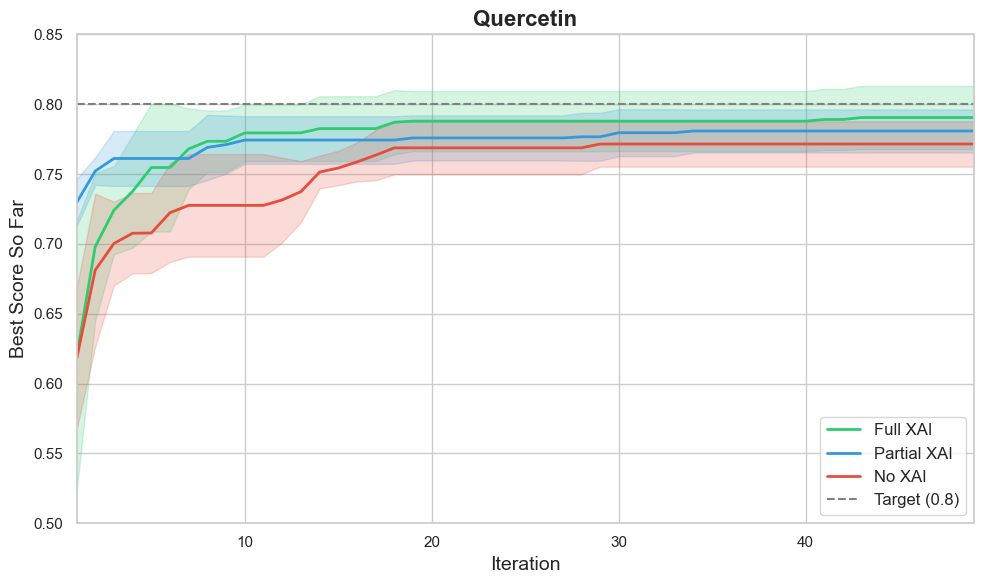

In [20]:
fig1, ax1 = plot_optimization_curves(
    relevant_data,
    title="Quercetin",
    target_score=0.8
)
plt.show()

## Plot 2: Weird Cyclodecane Optimization

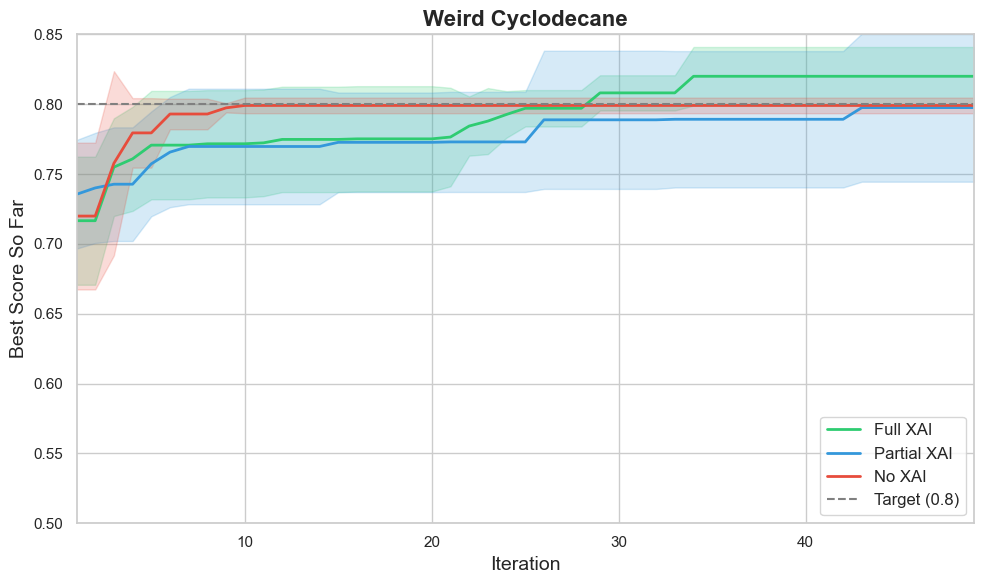

In [21]:
fig2, ax2 = plot_optimization_curves(
    random_data,
    title="Weird Cyclodecane",
    target_score=0.8
)
plt.show()

## Summary Statistics

In [22]:
def compute_summary_stats(data: dict[str, list[list[float]]]) -> pd.DataFrame:
    """Compute summary statistics for each XAI mode."""
    rows = []
    
    for xai_name, trajectories in data.items():
        if not trajectories:
            continue
        
        final_scores = [t[-1] for t in trajectories]
        iterations_to_complete = [len(t) for t in trajectories]
        
        rows.append({
            "XAI Mode": xai_name,
            "Repetitions": len(trajectories),
            "Final Score (mean ± std)": f"{np.mean(final_scores):.3f} ± {np.std(final_scores):.3f}",
            "Final Score (min)": f"{np.min(final_scores):.3f}",
            "Final Score (max)": f"{np.max(final_scores):.3f}",
            "Iterations (mean ± std)": f"{np.mean(iterations_to_complete):.1f} ± {np.std(iterations_to_complete):.1f}",
        })
    
    return pd.DataFrame(rows)

print("Summary Statistics - Quercetin:")
display(compute_summary_stats(relevant_data))

print("\nSummary Statistics - Weird Cyclodecane:")
display(compute_summary_stats(random_data))

Summary Statistics - Quercetin:


,XAI Mode,Repetitions,Final Score (mean ± std),Final Score (min),Final Score (max),Iterations (mean ± std)
0,Full XAI,5,0.790 ± 0.023,0.746,0.810,37.4 ± 12.1
1,Partial XAI,5,0.781 ± 0.016,0.761,0.800,44.0 ± 4.6
2,No XAI,5,0.771 ± 0.017,0.748,0.792,44.8 ± 2.6



Summary Statistics - Weird Cyclodecane:


,XAI Mode,Repetitions,Final Score (mean ± std),Final Score (min),Final Score (max),Iterations (mean ± std)
0,Full XAI,5,0.820 ± 0.021,0.793,0.856,27.2 ± 14.5
1,Partial XAI,5,0.798 ± 0.054,0.704,0.859,43.0 ± 8.8
2,No XAI,5,0.799 ± 0.006,0.793,0.809,38.8 ± 14.5


## Optimization Trajectory: QED vs Similarity

Scatter plots showing all evaluated molecules in the QED-Similarity space. Color indicates iteration number (darker = earlier, lighter = later).

In [23]:
def load_all_trace_data(results_dir: Path, molecule_type: str) -> dict[str, list[dict]]:
    """
    Load all trace entries for a given molecule type.
    
    Returns a dict mapping XAI mode to list of all trace entries (pooled from all repetitions).
    Each entry contains: iteration, smiles, score, scores (with Similarity and QED).
    """
    data = {}
    
    for xai_folder, xai_name in XAI_MODES.items():
        folder_path = results_dir / molecule_type / xai_folder
        all_entries = []
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                all_entries.extend(exp_data['trace'])
        
        data[xai_name] = all_entries
    
    return data


def plot_qed_similarity_scatter(data: dict[str, list[dict]], title: str, min_similarity: float = 0.7, min_qed: float = 0.7):
    """
    Plot scatter plots of QED vs Similarity for each XAI mode.
    Color indicates iteration number.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    xai_modes = ["Full XAI", "Partial XAI", "No XAI"]
    
    for ax, xai_name in zip(axes, xai_modes):
        entries = data.get(xai_name, [])
        if not entries:
            ax.set_title(f"{xai_name}\n(No data)")
            continue
        
        # Extract QED, Similarity, and iteration
        qed_vals = [e['scores']['QED'] for e in entries]
        sim_vals = [e['scores']['Similarity'] for e in entries]
        iterations = [e['iteration'] for e in entries]
        
        # Create scatter plot
        scatter = ax.scatter(qed_vals, sim_vals, c=iterations, cmap='viridis_r', 
                            alpha=0.7, s=15, edgecolors='none')
        
        # Add threshold lines
        ax.axvline(x=min_qed, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Min QED ({min_qed})')
        ax.axhline(y=min_similarity, color='blue', linestyle='--', linewidth=1, alpha=0.7, label=f'Min Sim ({min_similarity})')
        
        # Shade the "success" region
        ax.axvspan(min_qed, 1.0, ymin=(min_similarity - 0) / 1.0, ymax=1.0, alpha=0.1, color='green')
        
        ax.set_xlabel('QED', fontsize=12)
        ax.set_ylabel('Similarity', fontsize=12)
        ax.set_title(f"{xai_name}\n({len(entries)} points)", fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Iteration', fontsize=10)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig, axes

In [24]:
# Load trace data for both molecule types
quercetin_trace = load_all_trace_data(RESULTS_DIR, "relevant_molecule")
cyclodecane_trace = load_all_trace_data(RESULTS_DIR, "random_molecule")

print("Quercetin trace entries per XAI mode:")
for mode, entries in quercetin_trace.items():
    print(f"  {mode}: {len(entries)} entries")

print("\nWeird Cyclodecane trace entries per XAI mode:")
for mode, entries in cyclodecane_trace.items():
    print(f"  {mode}: {len(entries)} entries")

Quercetin trace entries per XAI mode:
  Full XAI: 187 entries
  Partial XAI: 220 entries
  No XAI: 224 entries

Weird Cyclodecane trace entries per XAI mode:
  Full XAI: 136 entries
  Partial XAI: 215 entries
  No XAI: 194 entries


### Quercetin: QED vs Similarity Trajectory

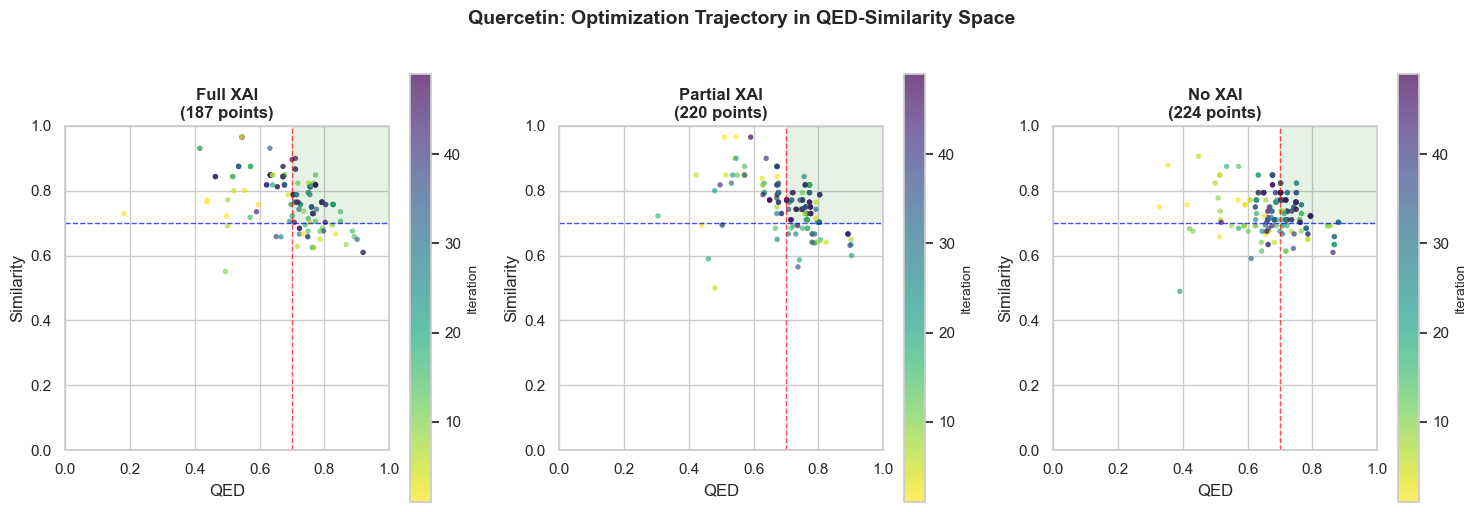

In [25]:
fig3, axes3 = plot_qed_similarity_scatter(
    quercetin_trace,
    title="Quercetin: Optimization Trajectory in QED-Similarity Space"
)
plt.show()

### Weird Cyclodecane: QED vs Similarity Trajectory

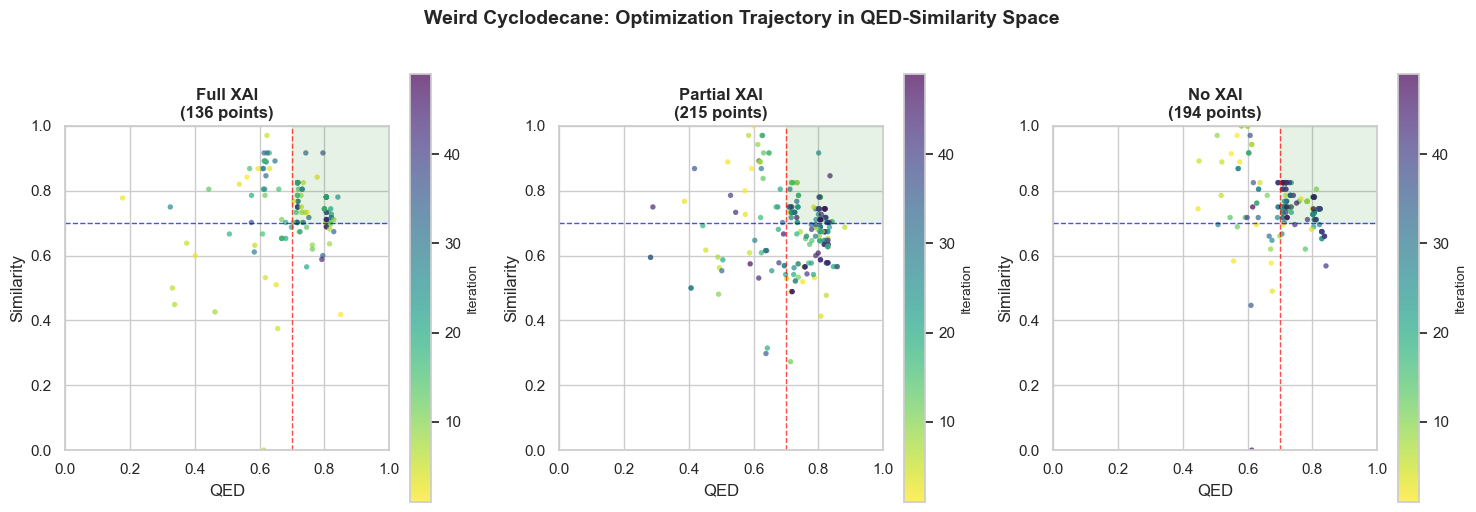

In [26]:
fig4, axes4 = plot_qed_similarity_scatter(
    cyclodecane_trace,
    title="Weird Cyclodecane: Optimization Trajectory in QED-Similarity Space"
)
plt.show()

## Molecule Visualization

Visualize the target molecules and the best optimized molecules found across all runs.

In [27]:
from rdkit import Chem
from rdkit.Chem import Draw, QED
from IPython.display import display

def find_best_molecule(results_dir: Path, molecule_type: str) -> dict:
    """Find the molecule with the highest score across all XAI modes and repetitions."""
    best_entry = None
    best_score = float('-inf')
    best_xai_mode = None
    best_rep = None
    
    for xai_folder, xai_name in XAI_MODES.items():
        folder_path = results_dir / molecule_type / xai_folder
        
        if folder_path.exists():
            json_files = sorted(folder_path.glob("*.json"))
            for json_file in json_files:
                exp_data = load_experiment_data(json_file)
                for entry in exp_data['trace']:
                    if entry['score'] > best_score:
                        best_score = entry['score']
                        best_entry = entry
                        best_xai_mode = xai_name
                        best_rep = json_file.stem
    
    return {
        'entry': best_entry,
        'xai_mode': best_xai_mode,
        'rep': best_rep
    }


def display_molecule_comparison(target_smiles: str, target_name: str, best_info: dict):
    """Display target molecule and best optimized molecule side by side."""
    best_entry = best_info['entry']
    best_smiles = best_entry['smiles']
    best_score = best_entry['score']
    best_scores = best_entry.get('scores', {})
    
    # Create molecule objects
    target_mol = Chem.MolFromSmiles(target_smiles)
    best_mol = Chem.MolFromSmiles(best_smiles)
    
    # Calculate QED for target molecule
    target_qed = QED.qed(target_mol)
    
    # Create images
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Target molecule
    target_img = Draw.MolToImage(target_mol, size=(400, 400))
    axes[0].imshow(target_img)
    axes[0].axis('off')
    axes[0].set_title(f"Target: {target_name}\nQED: {target_qed:.3f}", fontsize=14, fontweight='bold')
    
    # Best molecule
    best_img = Draw.MolToImage(best_mol, size=(400, 400))
    axes[1].imshow(best_img)
    axes[1].axis('off')
    
    # Build score string
    score_parts = [f"Score: {best_score:.3f}"]
    for name, val in best_scores.items():
        score_parts.append(f"{name}: {val:.3f}")
    score_str = " | ".join(score_parts)
    
    axes[1].set_title(f"Best Optimized ({best_info['xai_mode']})\n{score_str}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Target SMILES: {target_smiles}")
    print(f"Best SMILES:   {best_smiles}")
    print(f"Found in: {best_info['xai_mode']}, {best_info['rep']}")

### Quercetin: Target vs Best Optimized Molecule

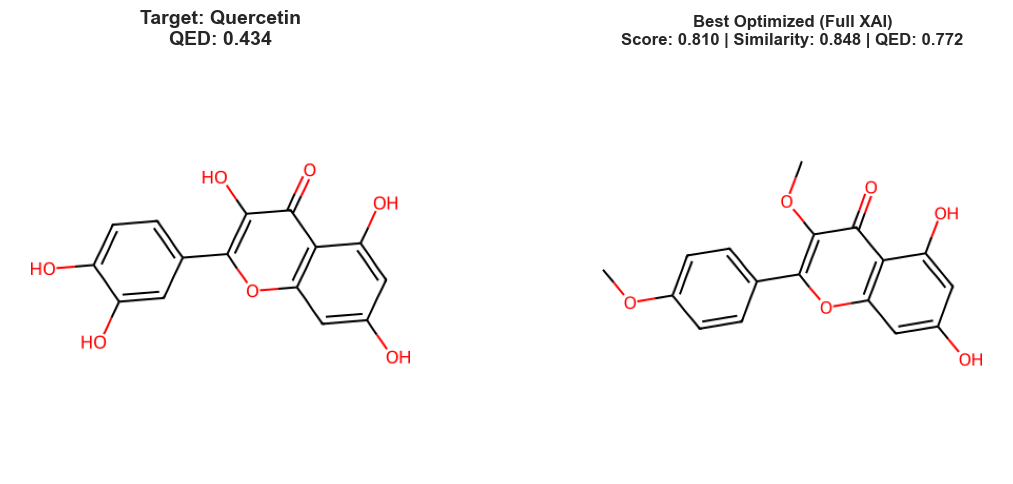

Target SMILES: O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O
Best SMILES:   O=C1c2c(O/C(=C1/OC)c3ccc(OC)cc3)cc(O)cc2O
Found in: Full XAI, sim_qed_relevant_full_rep2_conversation_20251208_114950


In [28]:
# Quercetin target SMILES
QUERCETIN_SMILES = "O=C1c3c(O/C(=C1/O)c2ccc(O)c(O)c2)cc(O)cc3O"

# Find best molecule for Quercetin experiments
quercetin_best = find_best_molecule(RESULTS_DIR, "relevant_molecule")

# Display comparison
display_molecule_comparison(QUERCETIN_SMILES, "Quercetin", quercetin_best)

### Weird Cyclodecane: Target vs Best Optimized Molecule

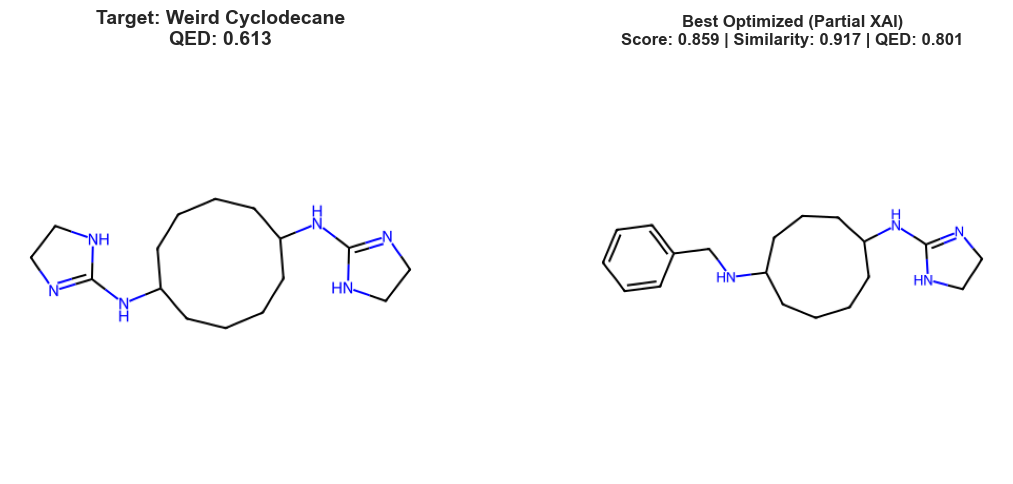

Target SMILES: C1CCC(CCCCC(C1)NC2=NCCN2)NC3=NCCN3
Best SMILES:   C1CCC(CCCC(C1)NCC2=CC=CC=C2)NC3=NCCN3
Found in: Partial XAI, sim_qed_random_partial_rep4_conversation_20251208_124324


In [29]:
# Weird Cyclodecane target SMILES
CYCLODECANE_SMILES = "C1CCC(CCCCC(C1)NC2=NCCN2)NC3=NCCN3"

# Find best molecule for Weird Cyclodecane experiments
cyclodecane_best = find_best_molecule(RESULTS_DIR, "random_molecule")

# Display comparison
display_molecule_comparison(CYCLODECANE_SMILES, "Weird Cyclodecane", cyclodecane_best)